In [59]:
# Import libraries
import numpy as np
import pandas as pd
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# Read CSV File
df = pd.read_csv('C:/Users/Brain/Desktop/accepted_2007_to_2018Q4.csv', low_memory=False)

In [61]:
# Keep only the variables we will use
df = df[[
    'loan_status',
    'int_rate',
    'term',
    'fico_range_low',
    'dti',
    'avg_cur_bal',
    'mort_acc',
    'loan_amnt',
    'inq_last_6mths',
    'bc_util',
    'revol_util',
    'grade',
    'verification_status',
    'home_ownership',
    'purpose']].copy()
    

In [62]:
# Remove rows where 'loan_status' is NA
df = df[df["loan_status"].notna() & (df["loan_status"].str.strip() != "")]
# Loan Status
df['loan_status'] = df['loan_status'].str.replace(
    "Does not meet the credit policy. Status:Charged Off",
    "Charged Off"
)
df['loan_status'] = df['loan_status'].str.replace(
    "Does not meet the credit policy. Status:Fully Paid",
    "Fully Paid"
)
# Keep only rows where loan_status = "Charged Off" or "Fully Paid"
df = df[df['loan_status'].isin(['Charged Off', 'Fully Paid'])].copy()

In [63]:
# Verification Status
# Combine 'Source Verified' and 'Verified'
df["verification_status"] = df["verification_status"].str.replace(
    "Source Verified", 
    "Verified"
)
df["verification_status"] = df["verification_status"].str.replace(
    "Not Verified", 
    "Not_Verified"
)
df['term'] = df['term'].str.replace(
    " months",
    ""
)
df['term'] = df['term'].str.replace(
    " ",
    ""
)

In [70]:
# Create dummy variables for all categorical variables
# loan_status, term, verification_status, home_ownership, purpose
columns_to_encode = ['loan_status','term','verification_status','home_ownership','purpose']
df_dummies = pd.get_dummies(
    df,
    columns= columns_to_encode,
    drop_first = True,
    dtype = int
)
df_dummies['loan_status_Charged Off'] = 1 - df_dummies['loan_status_Fully Paid']

#Now that columns are encoded, split loan grades using a df dictionary 
grades = df['grade'].unique()
grade_dfs = {}
for grade in grades:
    grade_dfs[grade] = df_dummies[df_dummies['grade'] == grade].reset_index(drop=True)

#Ran into some nulls that will need to be addressed before Regression
#Solution: replace nulls with median by grade
for col in ['avg_cur_bal', 'mort_acc', 'bc_util', 'dti', 'inq_last_6mths', 'revol_util']:
    for grade in grades:
        mask = df['grade'] == grade
        median_val = df.loc[mask, col].median()
        df.loc[mask, col] = df.loc[mask, col].fillna(median_val)

In [65]:
df_dummies.head()

,int_rate,fico_range_low,dti,avg_cur_bal,mort_acc,loan_amnt,inq_last_6mths,bc_util,revol_util,grade,loan_status_Fully Paid,term_60,verification_status_Verified,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,loan_status_Charged Off
0,13.99,675.0,5.91,20701.0,1.0,3600.0,1.0,37.2,29.7,C,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,11.99,715.0,16.06,9733.0,4.0,24700.0,4.0,27.1,19.2,C,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,10.78,695.0,10.78,31617.0,5.0,20000.0,0.0,55.9,56.2,B,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,22.45,695.0,25.37,27644.0,6.0,10400.0,3.0,77.5,64.5,F,1,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
5,13.44,690.0,10.20,2560.0,0.0,11950.0,0.0,91.0,68.4,C,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [66]:
print("Original variable names are:")
for col in df.columns:
    print(col)
print("\n\nDummy variable names:")    
for col in df_dummies.columns:
    print(col)

Original variable names are:
loan_status
int_rate
term
fico_range_low
dti
avg_cur_bal
mort_acc
loan_amnt
inq_last_6mths
bc_util
revol_util
grade
verification_status
home_ownership
purpose


Dummy variable names:
int_rate
fico_range_low
dti
avg_cur_bal
mort_acc
loan_amnt
inq_last_6mths
bc_util
revol_util
grade
loan_status_Fully Paid
term_60
verification_status_Verified
home_ownership_MORTGAGE
home_ownership_NONE
home_ownership_OTHER
home_ownership_OWN
home_ownership_RENT
purpose_credit_card
purpose_debt_consolidation
purpose_educational
purpose_home_improvement
purpose_house
purpose_major_purchase
purpose_medical
purpose_moving
purpose_other
purpose_renewable_energy
purpose_small_business
purpose_vacation
purpose_wedding
loan_status_Charged Off


In [27]:
# Can now do analysis on df_dummies

In [67]:
pd.set_option('display.max_columns', None)
df_dummies.head()

,int_rate,fico_range_low,dti,avg_cur_bal,mort_acc,loan_amnt,inq_last_6mths,bc_util,revol_util,grade,loan_status_Fully Paid,term_60,verification_status_Verified,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,loan_status_Charged Off
0,13.99,675.0,5.91,20701.0,1.0,3600.0,1.0,37.2,29.7,C,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,11.99,715.0,16.06,9733.0,4.0,24700.0,4.0,27.1,19.2,C,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,10.78,695.0,10.78,31617.0,5.0,20000.0,0.0,55.9,56.2,B,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,22.45,695.0,25.37,27644.0,6.0,10400.0,3.0,77.5,64.5,F,1,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
5,13.44,690.0,10.20,2560.0,0.0,11950.0,0.0,91.0,68.4,C,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [71]:
df_dummies.isnull().sum()

int_rate                        0
fico_range_low                  0
dti                             0
avg_cur_bal                     0
mort_acc                        0
loan_amnt                       0
inq_last_6mths                  0
bc_util                         0
revol_util                      0
grade                           0
loan_status_Fully Paid          0
term_60                         0
verification_status_Verified    0
home_ownership_MORTGAGE         0
home_ownership_NONE             0
home_ownership_OTHER            0
home_ownership_OWN              0
home_ownership_RENT             0
purpose_credit_card             0
purpose_debt_consolidation      0
purpose_educational             0
purpose_home_improvement        0
purpose_house                   0
purpose_major_purchase          0
purpose_medical                 0
purpose_moving                  0
purpose_other                   0
purpose_renewable_energy        0
purpose_small_business          0
purpose_vacati

In [30]:
grade_dfs['A'].shape

(235188, 31)

In [72]:
grade_dfs['A'].isnull().sum()

int_rate                        0
fico_range_low                  0
dti                             0
avg_cur_bal                     0
mort_acc                        0
loan_amnt                       0
inq_last_6mths                  0
bc_util                         0
revol_util                      0
grade                           0
loan_status_Fully Paid          0
term_60                         0
verification_status_Verified    0
home_ownership_MORTGAGE         0
home_ownership_NONE             0
home_ownership_OTHER            0
home_ownership_OWN              0
home_ownership_RENT             0
purpose_credit_card             0
purpose_debt_consolidation      0
purpose_educational             0
purpose_home_improvement        0
purpose_house                   0
purpose_major_purchase          0
purpose_medical                 0
purpose_moving                  0
purpose_other                   0
purpose_renewable_energy        0
purpose_small_business          0
purpose_vacati

#Ran into some nulls that will need to be addressed before Regression
#Solution: replace nulls with median by grade
for col in ['avg_cur_bal', 'mort_acc', 'bc_util', 'dti', 'inq_last_6mths', 'revol_util']:
    for grade in grades:
        mask = df['grade'] == grade
        median_val = df.loc[mask, col].median()
        df.loc[mask, col] = df.loc[mask, col].fillna(median_val)

In [73]:
# We'll be setting this all up inside a loop, so we don't need to manually address each grade
# Defining X & y; don't need grade in X since we're running models by grade
models = {}
grades = sorted(df['grade'].unique())
grade_auc_scores = {}
grade_preds = {}

#Setting up stratified K-Fold CV
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

for grade in grades:
    X = grade_dfs[grade].drop(columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade'])
    y = grade_dfs[grade]['loan_status_Charged Off']

    fold_scores = []
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
#Scale the data - Logistic regression is sensitive to scale. Fit only the training data!
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

#Fit & predict
        lreg = LogisticRegression(class_weight = 'balanced')
        lreg.fit(X_train_scaled, y_train)
        y_pred = lreg.predict(X_test_scaled)
        fold_scores.append(roc_auc_score(y_test, y_pred))
        
        
    models[grade] = lreg
    grade_auc_scores[grade] = np.mean(fold_scores)
    grade_preds[grade] = (y_test, y_pred)

#print out the results - Classification report, a confusion matrix, and ROC/AUC
    print('*' * 75)
    print('grade: ', grade)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_test, y_pred))
    print('*' * 75, '\n')

***************************************************************************
grade:  A
              precision    recall  f1-score   support

           0       0.96      0.57      0.71     22097
           1       0.09      0.65      0.16      1421

    accuracy                           0.57     23518
   macro avg       0.53      0.61      0.44     23518
weighted avg       0.91      0.57      0.68     23518

[[12565  9532]
 [  494   927]]
ROC-AUC:  0.6104933602043858
*************************************************************************** 

***************************************************************************
grade:  B
              precision    recall  f1-score   support

           0       0.89      0.56      0.69     34044
           1       0.17      0.57      0.26      5265

    accuracy                           0.56     39309
   macro avg       0.53      0.56      0.47     39309
weighted avg       0.80      0.56      0.63     39309

[[19012 15032]
 [ 2268  2997]]
ROC-A

Text(0.5, 1.0, 'Mean ROC-AUC by Loan Grade - Logistic Regression')

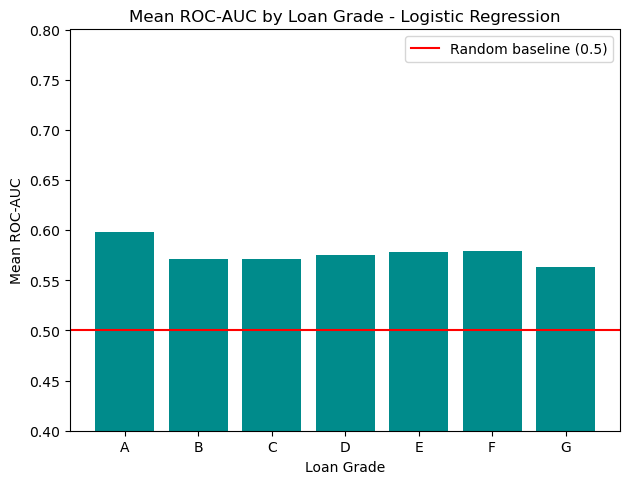

In [74]:
grades_sorted = sorted(grade_auc_scores.keys())
auc_values = [grade_auc_scores[g] for g in grades_sorted]

plt.bar(grades_sorted, auc_values, color = 'darkcyan')
plt.axhline(y = 0.5, color = 'red', label = 'Random baseline (0.5)')
plt.ylim(0.4,0.8)
plt.xlabel('Loan Grade')
plt.ylabel('Mean ROC-AUC')
plt.legend()
plt.tight_layout()
plt.title('Mean ROC-AUC by Loan Grade - Logistic Regression')

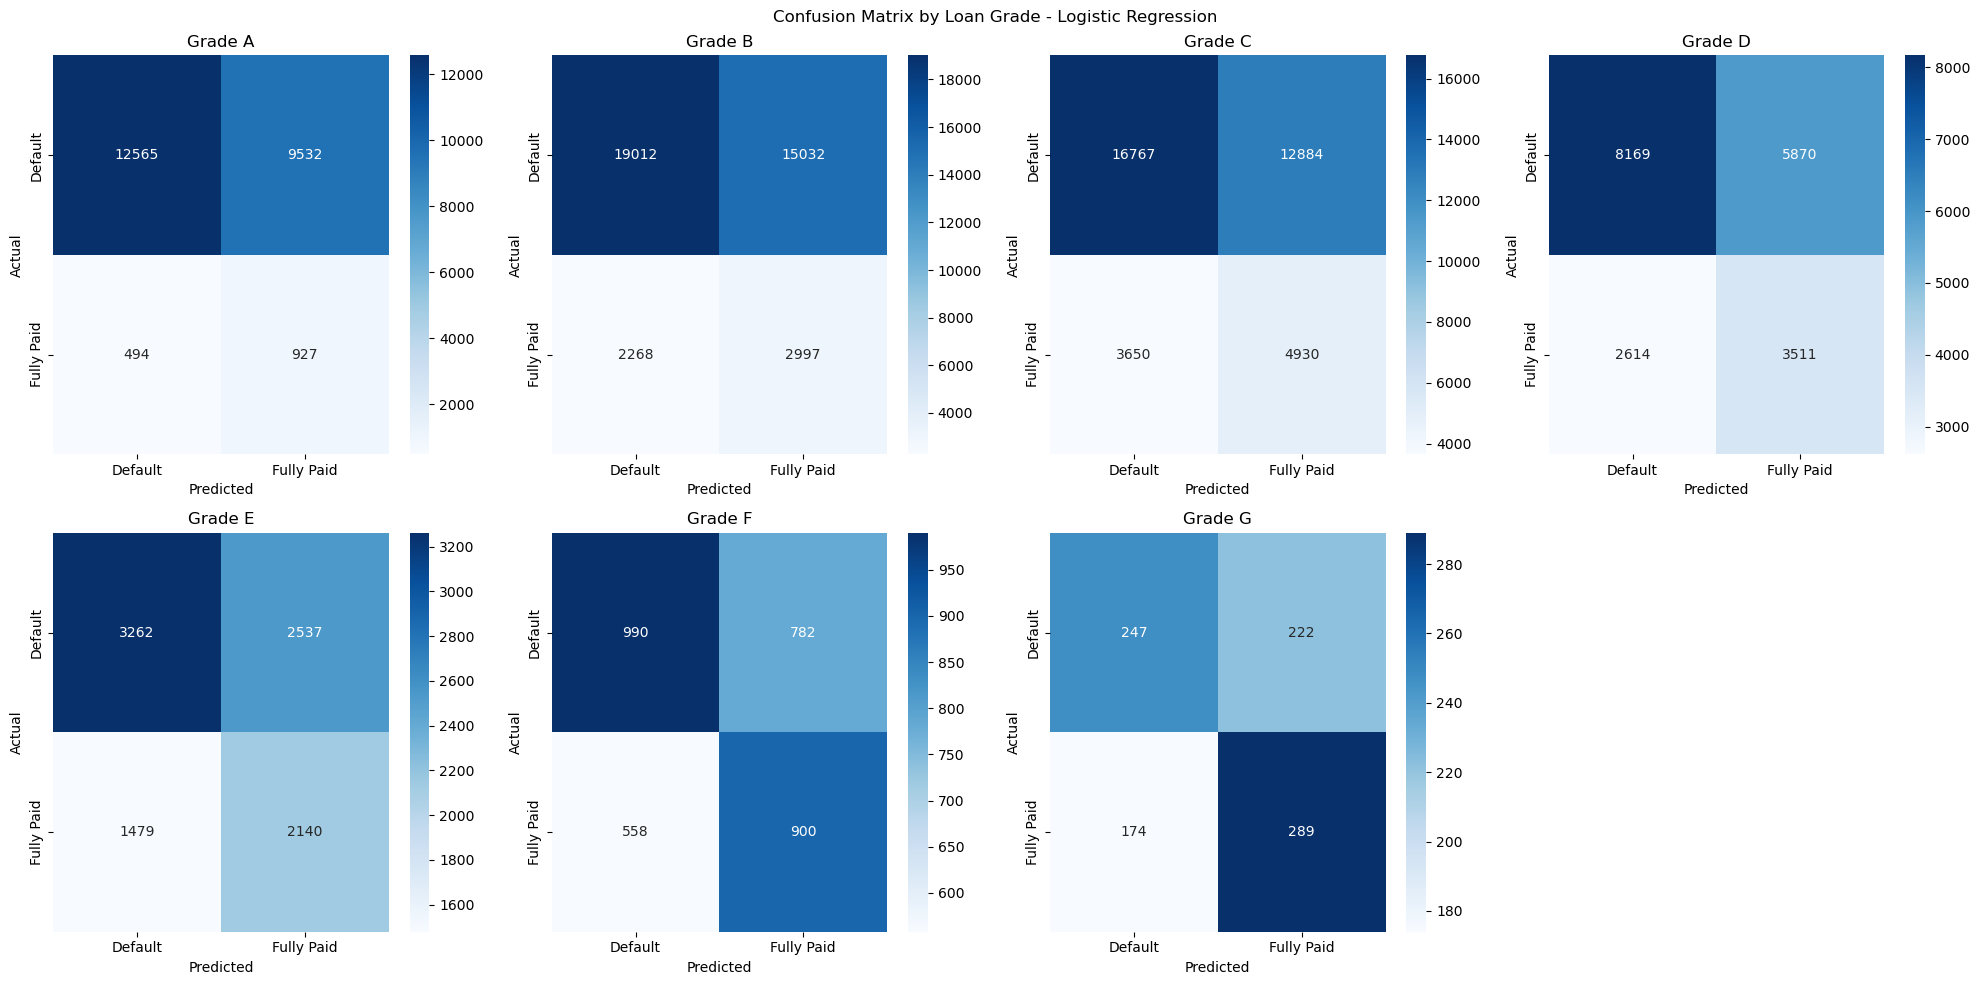

In [75]:
fig, axes = plt.subplots(2,4, figsize = (20,10))
axes = axes.flatten()
for index, grade in enumerate(grades_sorted):
    y_test, y_pred = grade_preds[grade]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot = True,
        fmt = 'd',
        cmap = 'Blues',
        ax = axes[index],
        xticklabels = ['Default', 'Fully Paid'],
        yticklabels = ['Default', 'Fully Paid']
    )
    axes[index].set_title(f'Grade {grade}')
    axes[index].set_ylabel('Actual')
    axes[index].set_xlabel('Predicted')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrix by Loan Grade - Logistic Regression')
plt.tight_layout()
plt.show()

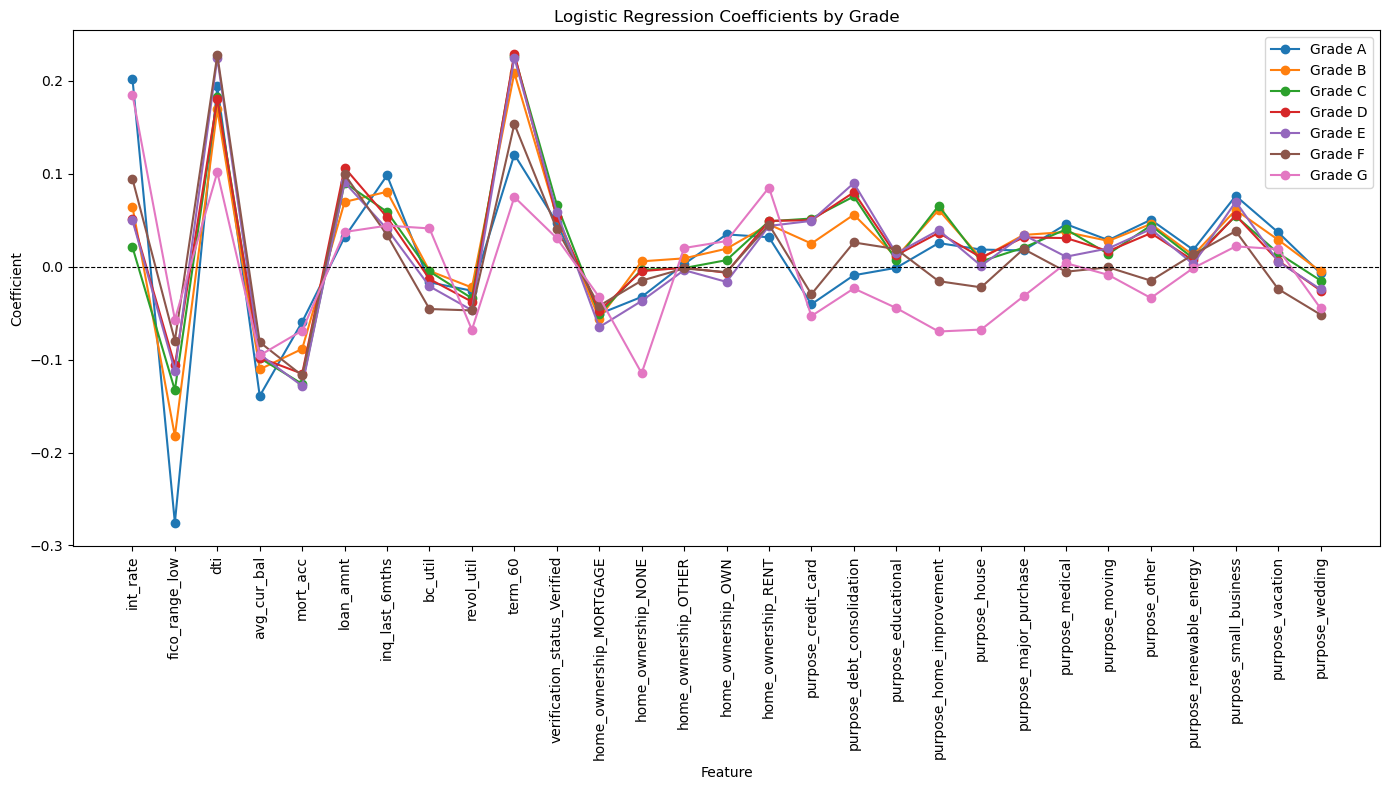

In [78]:
fig, ax = plt.subplots(figsize=(14, 8))

for grade in grades_sorted:
    model = models[grade]
    X = grade_dfs[grade].drop(columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade'])
    coefs = model.coef_[0]
    ax.plot(X.columns, coefs, marker='o', label=f'Grade {grade}')

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Feature')
ax.set_ylabel('Coefficient')
ax.set_title('Logistic Regression Coefficients by Grade')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()